# **Evaluación de técnicas de PLN en el razonamiento y la resolución de preguntas de comprensión lectora**

**Estudiantes: Sandra Conde González y Pablo Folgueira Galán**

---

En los últimos años, los LLMs han demostrado ser excepcionales en tareas generativas, llegando a convertirse en una herramienta imprescindible para muchas de las actividades que realizamos en nuestro día a día. Sin embargo, evaluar su nivel de razonamiento y comprensión del lenguaje natural es esencial para entender hasta qué punto son capaces de identificar matices semánticos y realizar inferencias complejas tal y como lo hacemos los humanos.

Con este objetivo, este proyecto se centra en evaluar el comportamiento de distintos modelos de lenguaje en la comprensión y la resolución de preguntas de opción múltiple que requieren una cierta complejidad en el razonamiento. Inicialmente, la idea surgió a partir de la tarea [PROFE 2025](https://sites.google.com/view/profe2025/home) de la campaña [IberLEF 2025](https://sites.google.com/view/iberlef-2025/home?authuser=0), centrada en evaluar la comprensión del lenguaje de este tipo de sistemas en distintas subtareas, siendo una de ellas la de respuesta a preguntas con múltiples opciones. Sin embargo, el conjunto de datos utilizado en esta competición aún no ha sido publicado, lo que imposibilita realizar una evaluación correcta de las distintas técnicas utilizadas a lo largo del notebook.

Por ello, se ha tomado como referencia la tarea [ReCoRES: Reading Comprehension and Reasoning Explanation for Spanish](https://codalab.lisn.upsaclay.fr/competitions/1696), presentada en [IberLEF 2022](https://sites.google.com/view/iberlef2022) y cuyo dataset sí ha sido publicado. De esta forma, no solo es posible realizar una evaluación rigurosa de los resultados obtenidos, sino también comparar el comportamiento de los modelos actuales con los de las propuestas realizadas por los participantes de la competición en el año 2022 (https://drive.google.com/file/d/1dikveD9G7DbX_tLFPW1KfhtgqFnKePsp/view?usp=sharing).

La tarea ReCoRES propone dos subtareas para evaluar la comprensión y el razonamiento de los modelos de lenguaje:

- Tarea 1 (múltiple opción): Dado un texto, una pregunta y una serie de posibles respuestas, el sistema debe escoger la respuesta correcta.

- Tarea 2 (explicación del razonamiento): Tras seleccionar una respuesta, el sistema debe generar una explicación que justifique la elección.

Respecto al dataset utilizado en esta tarea, los textos y las preguntas han sido obtenidos a partir de exámenes de entrada a la universidad de instituciones peruanas. Además, tratan sobre distintos temas y las preguntas requieren tener una cierta comprensión del texto, lo que permite evaluar la capacidad de los modelos de lenguaje para comprender textos complejos y razonar a partir de ellos.

Para tratar de resolver estas tareas, en este notebook se proponen distintas soluciones basadas en el *fine-tuning* de un modelo *encoder-only* y en la utilización de distintas técnicas de *prompt engineering* en modelos *decoder-only*, con el objetivo de compararlas y determinar cuál resulta más útil para este problema de comprensión del lenguaje.

In [ ]:
#@title Librerías necesarias
!pip install -q -U transformers datasets accelerate bitsandbytes sentencepiece evaluate bert_score
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, AutoModelForMultipleChoice, TrainingArguments, Trainer, DataCollatorForMultipleChoice
from transformers.tokenization_utils_base import PreTrainedTokenizerBase, PaddingStrategy
import pandas as pd
from google.colab import drive
import os
import torch
import numpy as np
from dataclasses import dataclass
import re
import json
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import gc
from datasets import load_dataset
import evaluate
from datasets import Dataset
from dataclasses import dataclass
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.6/536.6 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.3 MB/s eta 0:00:00


In [ ]:
#@title Carga del dataset ReCoRES y creación de los conjuntos de entrenamiento, validación y test

drive.mount('/content/drive')
path = '/content/drive/MyDrive/MASTER/PLN/00-proyecto/dataset-recores/'

train_df = pd.read_csv(os.path.join(path, 'train.csv'), sep='\t')
val_df = pd.read_csv(os.path.join(path, 'dev.csv'), sep='\t')
test_df = pd.read_csv(os.path.join(path, 'test.csv'), sep='\t')

print("--- Información del Conjunto de Entrenamiento ---")
train_df.info()

Mounted at /content/drive
--- Información del Conjunto de Entrenamiento ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1047 entries, 0 to 1046
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      1047 non-null   object
 1   question  1047 non-null   object
 2   A         1047 non-null   object
 3   B         1047 non-null   object
 4   C         1047 non-null   object
 5   D         1047 non-null   object
 6   E         1047 non-null   object
 7   answer    1047 non-null   object
 8   reason    1047 non-null   object
dtypes: object(9)
memory usage: 73.7+ KB


In [ ]:
#@title Visualización de algunos ejemplos del dataset

def mostrar_ejemplo(df, idx):
    row = df.iloc[idx]
    print(f"{'='*50}")
    print(f"PREGUNTA {idx}")
    print(f"{'='*50}")
    print(f"TEXTO:\n{row['text']}\n")
    print(f"PREGUNTA: {row['question']}")
    print(f"OPCIONES:")
    for letra in ['A', 'B', 'C', 'D', 'E']:
        print(f"  {letra}) {row[letra]}")
    print(f"{'-'*50}")
    print(f"RESPUESTA CORRECTA: {row['answer']}")
    print(f"EXPLICACIÓN: {row['reason']}")
    print(f"{'='*50}\n")

# Se muestran algunas preguntas del conjunto de entrenamiento
for num_preg in [1, 5, 13]:
  mostrar_ejemplo(train_df, num_preg)

PREGUNTA: 1
TEXTO:
El trabajo es en primer término un proceso entre la naturaleza y el hombre, proceso en que este realiza, regula y controla mediante su propia acción su intercambio de materias con la naturaleza. En este proceso, el hombre se enfrenta como un poder natural con la materia de la naturaleza. Pone en acción las fuerzas naturales que forman su corporeidad, los brazos y las piernas, la cabeza y la mano, para de ese modo asimilarse, bajo una forma útil para su propia vida, las materias que la naturaleza le brinda. Y a la par que de ese modo actúa sobre la naturaleza exterior a él y la transforma, transforma su propia naturaleza, desarrollando las potencias que dormitan en él y sometiendo el juego de sus fuerzas a su propia disciplina. Aquí no vamos a ocuparnos de las primeras formas de trabajo, formas instintivas y de tipo animal. Aquí, partimos del supuesto del trabajo plasmado ya bajo una forma en la que pertenece exclusivamente al hombre. Una araña ejecuta operaciones que

# **MÉTRICAS DE EVALUACIÓN PARA CADA TAREA**

Para poder evaluar los resultados de las distintas técnicas, se han tomado como referencia algunas de las métricas utilizadas en la propuesta original ([ReCoRES: Reading Comprehension and Reasoning Explanation for Spanish](https://drive.google.com/file/d/1dikveD9G7DbX_tLFPW1KfhtgqFnKePsp/view?usp=sharing)). En ella, se utiliza el ***accuracy*** para la primera tarea (múltiple opción), midiendo el porcentaje de preguntas acertadas y, para la segunda (explicación del razonamiento), se usa ***BERTScore*** ([Zhang et al., 2020](https://arxiv.org/abs/1904.09675)), que determina la similitud entre la explicación proporcionada en el dataset y la generada por el modelo.

Para medir los resultados de la segunda tarea se planteó el uso de otras métricas como *BLEU* o *ROUGE*, que se basan en la coincidencia de palabras, por lo que los resultados podrían ser bastante bajos y poco representativos. Sin embargo, *BERTScore*, al utilizar un modelo tipo *BERT* preentrenado para generar embeddings y calcular la similitud entre el correspondiente a la explicación proporcionada y al de la explicación generada, es capaz de relacionar palabras sinónimas o que puedan utilizarse en contextos similares, de forma que la métrica es mucho más representativa y permite evaluar mejor la calidad de la explicación.

# **FINE-TUNING**

La primera técnica que se va a utilizar para intentar resolver el problema es hacer ***fine-tuning*** sobre un modelo ***encoder-only***. Como este tipo de modelos no son capaces de generar texto, la estrategia utilizada se centrará en resolver la **tarea 1 (multiple choice)**, que consiste en seleccionar la respuesta (letra) correcta a la pregunta entre las opciones posibles. Siguiendo esta aproximación, se seleccionará un modelo preentrenado de este tipo y se ajustarán sus pesos para que se especialice en responder a preguntas de comprensión lectora con varias opciones posibles y solo una respuesta correcta.

## Definición de las funciones de tokenización y métrica de evaluación

Al modelo le entrará el texto, la pregunta y únicamente una respuesta cada vez, de forma que la salida será la probabilidad de que esa respuesta se relacione con el texto y la pregunta. Por tanto, la respuesta correcta será la que tenga una mayor probabilidad.

De esta forma, en la función de tokenización cada texto se replica tantas veces como número de respuestas haya para cada pregunta (en nuestro caso, 4 opciones de respuesta para el dataset *RACE*, que se mencionará más adelante, y 5 opciones para el dataset ReCoRES). Además, para tokenizar cada uno de estos textos, se ha tomado la decisión de truncar aquellos que superen los 512 tokens, sacrificando algo de precisión para respetar los límites de Google Colab. El padding necesario para igualar la longitud de todos los textos de un batch se encargará de realizarlo posteriormente el DataCollator, de forma que se ajuste dinámicamente al texto de mayor longitud de cada batch específico.

In [ ]:
#@title Función de tokenización
def tokenize_dataset(data, num_options, label_map=None):
    """
    Convierte un texto y su pregunta con 'num_options' respuestas en 'num_options' entradas distintas
    para el modelo y las tokeniza.

    Input:
      - data: conjunto de datos a tokenizar
      - num_options: número de respuestas posibles a la pregunta

    Output:
      Devuelve el conjunto de datos tokenizado
    """
    # Lista donde cada texto aparece repetido 4 veces
    texts = [[text] * num_options for text in data["article"]]
    texts = sum(texts, [])
    # Lista con cada pregunta emparejada con cada una de las respuestas
    question_and_answer = [
        [f"{q} {opt}" for opt in options] for q, options in zip(data["question"], data["options"])
    ]
    question_and_answer = sum(question_and_answer, [])

    # Tokenización
    tokenized_data = tokenizer(
        texts,
        question_and_answer,
        truncation=True, # Trunca el texto si supera el tamaño máximo permitido por el modelo
        max_length = 512,
        padding=False # El dataCollator se encarga del padding al crear los batches
    )

    # Agrupa las opciones por pregunta
    unflattened = {k: [v[i : i + num_options] for i in range(0, len(v), num_options)] for k, v in tokenized_data.items()}

    if label_map is None:
      unflattened["label"] = data["answer"]
    else:
      # Mapea las respuestas (A,B,C,D) a 0,1,2,3
      unflattened["label"] = [label_map[letter] for letter in data["answer"]]
    return unflattened

In [ ]:
#@title Función de evaluación *accuracy*
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

## Modelo utilizado

El modelo elegido ha sido ***[mDeBERTa](https://huggingface.co/microsoft/mdeberta-v3-base)*** en su versión base, perteneciente a la familia de modelos *BERT*, que destaca por ser más moderno y eficiente que otros predecesores más conocidos como *XLM-RoBERTa*. La característica principal de *mDeBERTa* (*Multilingual Decoding-enhanced BERT with disentangled attention*) es que ha sido preentrenado con un corpus que incluye 100 idiomas diferentes, lo que le permite aprender representaciones semánticas compartidas entre el inglés y el español, por ejemplo, gracias a una arquitectura mejorada en el mecanismo de atención. Esto es muy necesario para el problema que se quiere resolver, pues el dataset ReCoRES cuenta con un número muy limitado de ejemplos en español, lo que dificulta que el modelo aprenda la tarea de razonamiento y comprensión lectora si se entrena únicamente con ellos, dando lugar a *overfitting* o a una incapacidad para generalizar bien ante nuevos textos. Por este motivo, se ha optado por hacer uso del dataset *[RACE](https://huggingface.co/datasets/ehovy/race)*, que contiene más de 28.000 textos con preguntas y varias opciones de respuesta extraídos de exámenes de inglés de educación secundaria y bachillerato en China. De esta forma, se proporcionan al modelo una gran cantidad de ejemplos de comprensión lectora en inglés, permitiéndole aprender patrones generales de razonamiento e inferencia que luego podrán transferirse al español.

Por todo ello, se realizan dos *fine-tunings* al modelo *mDeBERTa* gracias a su capacidad de transferencia entre idiomas:

### 1. *Fine-tuning* con el dataset *RACE* (Inglés)

En primer lugar, se entrena el modelo utilizando 20.000 ejemplos del dataset *RACE* durante 2 épocas, de forma que pueda aprender la tarea de resolución de preguntas de opción múltiple con una gran cantidad de ejemplos distintos. Se ha decidido este número de épocas teniendo en cuenta que un entrenamiento más largo superaría los límites permitidos por Google Colab y, además, porque al final del entrenamiento se aprecia un ligero *overfitting*, ya que el *accuracy* de los últimos 300 batches apenas mejora.

Una vez finalizado el *fine-tuning*, los resultados sobre el conjunto de validación de *RACE* indican que el modelo ha convergido, alcanzando un 64.68% de *accuracy* y reduciendo el *loss* a un 0.914.

Además, se ha probado el desempeño de este modelo entrenado únicamente con ejemplos en inglés sobre el conjunto de test de ReCoRES, obteniendo un *accuracy* de tan sólo 27.72%. Esto demuestra que, tras únicamente esta primera fase de *fine-tuning*, el modelo no ha sido capaz de aprender a realizar inferencias sobre textos en español que requieren una cierta complejidad. Esto se intentará mejorar con una segunda fase de especialización, utilizando el dataset concreto de la tarea ReCoRES que contiene textos en español.

In [ ]:
#@title Carga del dataset *RACE* y del modelo *mdberta-v3-base*
model_id = "microsoft/mdeberta-v3-base"

# Carga del dataset RACE
dataset = load_dataset("race", "all")

# Se utilizan 20000 textos del conjunto de entrenamiento para respetar los límites de Google Colab
dataset["train"] = dataset["train"].shuffle(seed=42).select(range(20000))

model = AutoModelForMultipleChoice.from_pretrained(model_id)


README.md: 0.00B [00:00, ?B/s]

all/test-00000-of-00001.parquet:   0%|          | 0.00/2.08M [00:00<?, ?B/s]

all/train-00000-of-00001.parquet:   0%|          | 0.00/37.4M [00:00<?, ?B/s]

all/validation-00000-of-00001.parquet:   0%|          | 0.00/2.05M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4934 [00:00<?, ? examples/s]

...

Generating validation split:   0%|          | 0/4887 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of DebertaV2ForMultipleChoice were not initialized from the model checkpoint at microsoft/mdeberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#@title Visualización del número de ejemplos para cada conjunto del dataset *RACE*
print(dataset)

DatasetDict({
    test: Dataset({
        features: ['example_id', 'article', 'answer', 'question', 'options'],
        num_rows: 4934
    })
    train: Dataset({
        features: ['example_id', 'article', 'answer', 'question', 'options'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['example_id', 'article', 'answer', 'question', 'options'],
        num_rows: 4887
    })
})


In [ ]:
#@title Tokenización del dataset *RACE*
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Mapa para convertir respuestas 'A','B','C','D' a índices 0,1,2,3
label2id = {"A": 0, "B": 1, "C": 2, "D": 3}

tokenized_RACE = dataset.map(tokenize_dataset, batched=True, remove_columns=dataset["train"].column_names, fn_kwargs={"num_options": 4, "label_map": label2id})

# Aplana todas las entradas del modelo, les aplica el padding y luego desaplana los resultados formando los batches
collator = DataCollatorForMultipleChoice(tokenizer=tokenizer)

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/4934 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4887 [00:00<?, ? examples/s]

In [ ]:
#@title *Fine-tuning* del modelo *mdeberta-v3-base* con el dataset *RACE*
training_args = TrainingArguments(
    output_dir="./mdeberta-v3-race-finetuned",
    learning_rate=3e-5,
    num_train_epochs=2,
    eval_strategy="steps",
    eval_steps=300,
    save_strategy="steps",
    save_steps=300,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=16,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=True,
    optim="adamw_torch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=150,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_RACE["train"],
    eval_dataset=tokenized_RACE["validation"],
    processing_class=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.
You're using a DebertaV2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss,Validation Loss,Accuracy
300,1.236900,1.090392,0.540004
600,1.052800,0.966020,0.603847
900,0.850800,0.936775,0.639452
1200,0.813800,0.914119,0.646818


TrainOutput(global_step=1250, training_loss=1.0161236114501953, metrics={'train_runtime': 10582.9056, 'train_samples_per_second': 3.78, 'train_steps_per_second': 0.118, 'total_flos': 3.858360434705966e+16, 'train_loss': 1.0161236114501953, 'epoch': 2.0})

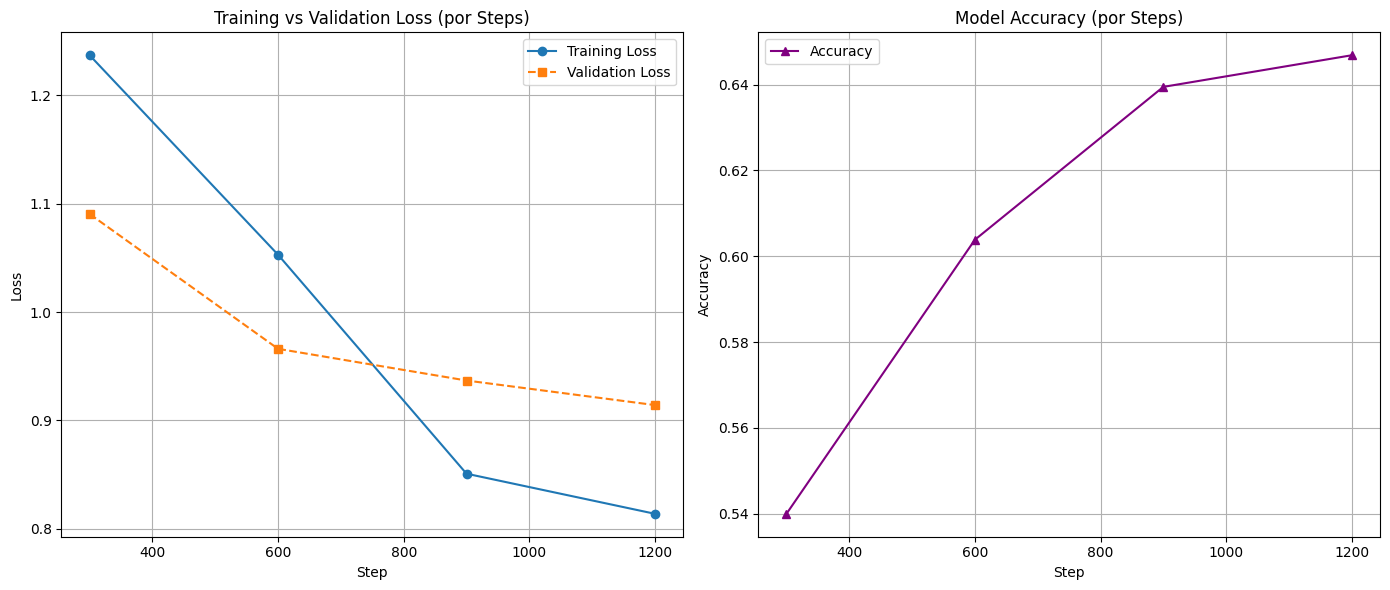

In [ ]:
#@title Gráficas de pérdida y accuracy durante el *fine-tuning* con el dataset *RACE*
training_data = {
    'Step': [300, 600, 900, 1200],
    'Training Loss': [1.236900, 1.052800, 0.850800, 0.813800],
    'Validation Loss': [1.090392, 0.966020, 0.936775, 0.914119],
    'Accuracy': [0.540004, 0.603847, 0.639452, 0.646818]
}

df_steps = pd.DataFrame(training_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica Loss
ax1.plot(df_steps['Step'], df_steps['Training Loss'], label='Training Loss', marker='o', linestyle='-')
ax1.plot(df_steps['Step'], df_steps['Validation Loss'], label='Validation Loss', marker='s', linestyle='--')
ax1.set_title('Training vs Validation Loss (por Steps)')
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Gráfica Accuracy
ax2.plot(df_steps['Step'], df_steps['Accuracy'], label='Accuracy', color='purple', marker='^', linestyle='-')
ax2.set_title('Model Accuracy (por Steps)')
ax2.set_xlabel('Step')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

In [ ]:
#@title Guardado del modelo *fine-tuneado* con el dataset *RACE*
path = '/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-RACE/'

trainer.save_model(path)
tokenizer.save_pretrained(path)

('/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-RACE/tokenizer_config.json',
 '/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-RACE/special_tokens_map.json',
 '/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-RACE/spm.model',
 '/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-RACE/added_tokens.json',
 '/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-RACE/tokenizer.json')

In [ ]:
#@title Carga del modelo *fine-tuneado* con el dataset *RACE*
drive.mount('/content/drive')
path = "/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-RACE/"

tokenizer = AutoTokenizer.from_pretrained(path, use_fast=True, fix_mistral_regex=True)
model = AutoModelForMultipleChoice.from_pretrained(path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

DebertaV2ForMultipleChoice(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(251000, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((76

In [ ]:
#@title Carga y preprocesamiento del dataset ReCoRES
path = '/content/drive/MyDrive/MASTER/PLN/00-proyecto/dataset-recores/'

train_df = pd.read_csv(os.path.join(path, 'train.csv'), sep='\t')
val_df = pd.read_csv(os.path.join(path, 'dev.csv'), sep='\t')
test_df = pd.read_csv(os.path.join(path, 'test.csv'), sep='\t')

# Mapea las respuestas (A,B,C,D,E) a 0,1,2,3,4
label_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}

def format_row(row):
    # Lista con las 5 opciones posibles
    options = [str(row["A"]), str(row["B"]), str(row["C"]), str(row["D"]), str(row["E"])]
    answer = label_map.get(row["answer"].strip(), -1)
    return {"article": row["text"], "question": row["question"], "options": options, "answer": answer}

# Convierte los datasets a un objeto Dataset de HuggingFace para el fine-tuning
formatted_train_data = train_df.apply(format_row, axis=1, result_type='expand')
train_dataset = Dataset.from_pandas(formatted_train_data)

formatted_val_data = val_df.apply(format_row, axis=1, result_type='expand')
val_dataset = Dataset.from_pandas(formatted_val_data)

formatted_test_data = test_df.apply(format_row, axis=1, result_type='expand')
test_dataset = Dataset.from_pandas(formatted_test_data)

# Tokeniza los conjuntos de entrenamiento, validación y test del dataset ReCoRES
tokenized_train_recores = train_dataset.map(tokenize_dataset, batched=True, remove_columns=train_dataset.column_names, fn_kwargs={"num_options": 5})
tokenized_val_recores = val_dataset.map(tokenize_dataset, batched=True, remove_columns=val_dataset.column_names, fn_kwargs={"num_options": 5})
tokenized_test_recores = test_dataset.map(tokenize_dataset, batched=True, remove_columns=test_dataset.column_names, fn_kwargs={"num_options": 5})

# Aplana todas las entradas del modelo, les aplica el padding y luego desaplana los resultados formando batches
collator = DataCollatorForMultipleChoice(tokenizer=tokenizer)

Map:   0%|          | 0/1047 [00:00<?, ? examples/s]

Map:   0%|          | 0/363 [00:00<?, ? examples/s]

Map:   0%|          | 0/386 [00:00<?, ? examples/s]

In [ ]:
#@title Evaluación del modelo *fine-tuneado* con el dataset *RACE* sobre el conjunto de test del dataset *ReCoRES*
training_args = TrainingArguments(
    output_dir="./resultados_test",
    per_device_eval_batch_size=4,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    tokenizer=tokenizer,
    data_collator=collator,
)

predictions = trainer.predict(tokenized_test_recores)

# Cálculo del accuracy sobre el conjunto de test del dataset ReCoRES
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids
accuracy = evaluate.load("accuracy")
resultado = accuracy.compute(predictions=preds, references=labels)

print("\n" + "="*30)
print(f"RESULTADO SOBRE EL CONJUNTO DE TEST")
print(f"Accuracy: {resultado['accuracy']:.2%}")
print("="*30)

/tmp/ipython-input-981524031.py:7: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
You're using a DebertaV2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



RESULTADO SOBRE EL CONJUNTO DE TEST
Accuracy: 27.72%


### 2. *Fine-tuning* con el dataset ReCoRES (Español)

A partir del modelo anterior, se ha realizado un segundo *fine-tuning* utilizando el conjunto de entrenamiento de ReCoRES durante 10 épocas, con el objetivo de que aprenda a transferir el razonamiento aprendido en inglés a la semántica del español. En este caso, se ha aumentado el número de épocas de entrenamiento a 10 dado que el dataset ReCoRES es mucho más pequeño y, por tanto, la duración del entrenamiento por época es menor y el modelo necesita más tiempo para poder aprender patrones dentro de estos datos.

Tras este segundo *fine-tuning*, los resultados sobre el conjunto de validación de ReCoRES muestran un *accuracy* máximo de 42.69% y un *loss* mínimo de 2.13.

Por último, evaluando el modelo definitivo sobre el conjunto de test de ReCoRES, se ha obtenido un *accuracy* de 40.93%, superior al obtenido por el modelo tras el entrenamiento con ejemplos sólo en inglés. Por tanto, el preentrenamiento de mDeBERTa en inglés ha supuesto una mejora sustancial y ha permitido al modelo posteriormente especializarse en la resolución de preguntas de múltiple opción en español a pesar de la limitación de ejemplos en este idioma. Sin embargo, los resultados obtenidos no son del todo buenos y, además, durante las últimas épocas se puede ver que el modelo está sobreaprendiendo.

Por tanto, se concluye que, con los modelos que existen actualmente, la técnica de *fine-tuning* sobre un modelo *encoder-only* puede no ser la mejor aproximación, ya que es muy dependiente de la capacidad de cómputo disponible y de la calidad y cantidad de los datos necesarios para realizar el entrenamiento, siendo mucho más escasos en el idioma español para esta tarea específica. Es por ello que se tratará de obtener mejores resultados aplicando distintas técnicas de *prompt engineering* que no tienen estas limitaciones.

In [ ]:
#@title *Fine-tuning* del modelo *mdeberta-v3-base* con el dataset *ReCoRES*
training_args = TrainingArguments(
    output_dir="./mdeberta-v3-recores-finetuned",
    learning_rate=2e-5,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=True,
    save_total_limit=1,
    optim="adamw_torch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_recores,
    eval_dataset=tokenized_val_recores,
    processing_class=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.632100,1.560965,0.297521
2,1.575800,1.526431,0.349862
3,1.524900,1.520237,0.371901
4,1.218000,1.573516,0.385675
5,1.045500,1.761690,0.380165
6,0.918100,1.903548,0.410468
7,0.648900,2.138691,0.424242
8,0.538700,2.176651,0.426997
9,0.511400,2.474676,0.410468
10,0.426800,2.458485,0.410468


TrainOutput(global_step=660, training_loss=0.9675359082944466, metrics={'train_runtime': 4481.8467, 'train_samples_per_second': 2.336, 'train_steps_per_second': 0.147, 'total_flos': 1.372706349171198e+16, 'train_loss': 0.9675359082944466, 'epoch': 10.0})

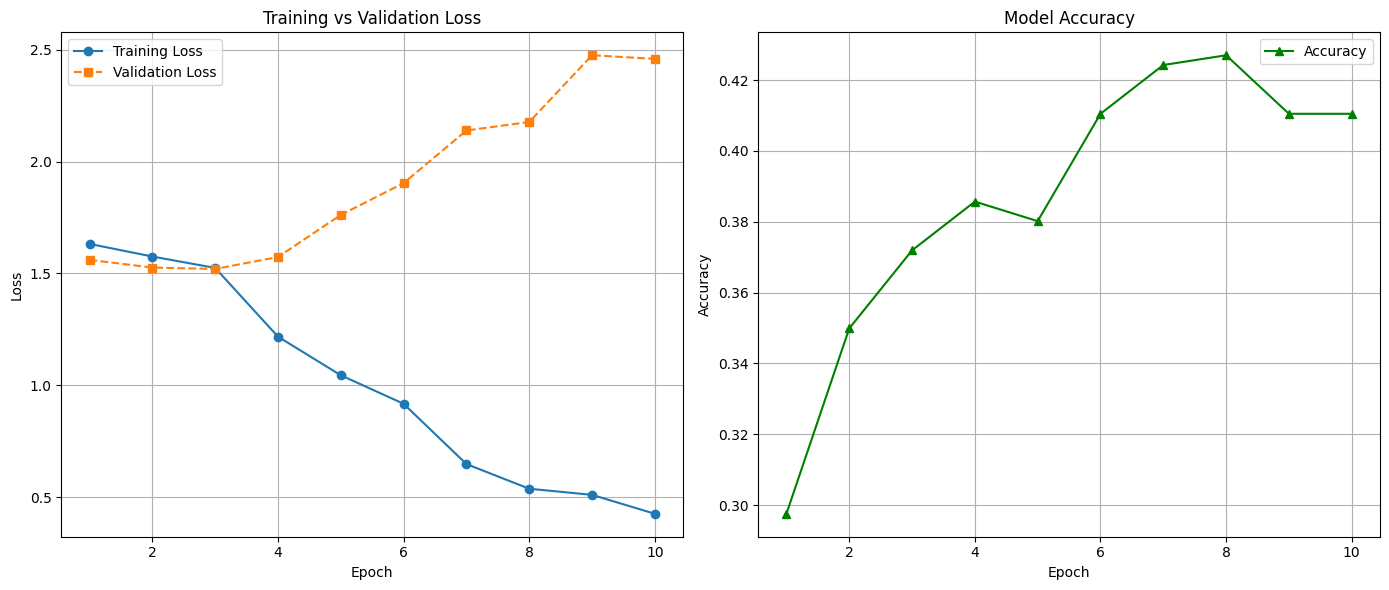

In [ ]:
#@title Gráficas de pérdida y accuracy durante el *fine-tuning* con el dataset ReCoRES
# Métricas del entrenamiento
training_data = {
    'Epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Training Loss': [1.632100, 1.575800, 1.524900, 1.218000, 1.045500, 0.918100, 0.648900, 0.538700, 0.511400, 0.426800],
    'Validation Loss': [1.560965, 1.526431, 1.520237, 1.573516, 1.761690, 1.903548, 2.138691, 2.176651, 2.474676, 2.458485],
    'Accuracy': [0.297521, 0.349862, 0.371901, 0.385675, 0.380165, 0.410468, 0.424242, 0.426997, 0.410468, 0.410468]
}

df = pd.DataFrame(training_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica Loss
ax1.plot(df['Epoch'], df['Training Loss'], label='Training Loss', marker='o', linestyle='-')
ax1.plot(df['Epoch'], df['Validation Loss'], label='Validation Loss', marker='s', linestyle='--')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Gráfica Accuracy
ax2.plot(df['Epoch'], df['Accuracy'], label='Accuracy', color='green', marker='^', linestyle='-')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()

In [ ]:
#@title Guardado del modelo
path = '/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-ReCoRES/'

trainer.save_model(path)
tokenizer.save_pretrained(path)

('/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-ReCoRES/tokenizer_config.json',
 '/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-ReCoRES/special_tokens_map.json',
 '/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-ReCoRES/spm.model',
 '/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-ReCoRES/added_tokens.json',
 '/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-ReCoRES/tokenizer.json')

In [ ]:
#@title Carga del modelo *fine-tuneado* con el dataset ReCoRES
path = "/content/drive/MyDrive/MASTER/PLN/00-proyecto/mdeberta-fine-tuning-ReCoRES/"

tokenizer = AutoTokenizer.from_pretrained(path, use_fast=True, fix_mistral_regex=True)
model = AutoModelForMultipleChoice.from_pretrained(path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


DebertaV2ForMultipleChoice(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(251000, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((76

In [ ]:
#@title Resultados sobre el conjunto de test del dataset ReCoRES

training_args = TrainingArguments(
    output_dir="./resultados_test",
    per_device_eval_batch_size=4,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    tokenizer=tokenizer,
    data_collator=collator,
)

predictions = trainer.predict(tokenized_test_recores)

# Cálculo del accuracy sobre el conjunto de test del dataset ReCoRES
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids
accuracy = evaluate.load("accuracy")
resultado = accuracy.compute(predictions=preds, references=labels)

print("\n" + "="*30)
print(f"RESULTADO SOBRE EL CONJUNTO DE TEST")
print(f"Accuracy: {resultado['accuracy']:.2%}")
print("="*30)

/tmp/ipython-input-473415344.py:9: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



RESULTADO SOBRE EL CONJUNTO DE TEST
Accuracy: 40.93%


# **PROMPT ENGINEERING**

La segunda técnica que se ha explorado para intentar resolver el problema es realizar ***prompt engineering*** sobre modelos ***decoder-only***. A diferencia de la aproximación anterior, donde se buscaba ajustar los pesos del modelo, el objetivo en este caso es optimizar la entrada de datos para guiar el razonamiento del modelo hacia la tarea de resolución de preguntas de comprensión lectora siguiendo un formato de salida estructurado.

En primer lugar, para que las respuestas generadas por el modelo sigan una misma estructura fácilmente procesable y estable, se ha configurado el *system prompt* con una instrucción que obliga al modelo a seguir el siguiente **formato JSON de salida**:
```
{
  "explicacion": "Explicación de la respuesta elegida en base al texto.",
  "respuesta": "Letra de la opción correcta elegida (A, B, C, D o E)."
}
```
Para utilizar la técnica ***chain of thought***, explicada posteriormente, este JSON de salida se ha modificado añadiendo un nuevo campo donde el modelo pueda realizar el razonamiento necesario:

```
{
  "razonamiento": "Razonamiento paso a paso descartando opciones.",
  "explicacion": "Explicación de la respuesta elegida en base al texto.",
  "respuesta": "Letra de la opción correcta elegida (A, B, C, D o E)."
}
```
Además, se pide al modelo que devuelva primero los campos "razonamiento", en el caso de *CoT*, y "explicacion", de forma que antes de decidir cual es la respuesta definitiva (letra) para el campo "respuesta", debe realizar un razonamiento lógico para generar la explicación en base al texto y pregunta dados, reduciendo así la probabilidad de que el modelo responda aleatoriamente.

## Técnicas de *prompt engineering* utilizadas

Los cuatro tipos de *prompting* que se han implementado son los siguientes:

- ***Zero-Shot Prompting***. El modelo recibe en el user prompt únicamente el texto, la pregunta y las opciones, sin ninguna instrucción adicional que le indique cómo resolver casos similares:
```
BASIC_USER_PROMPT = "Texto: {text}
                      Pregunta: {question}
                      Opciones:\n{options}
                      Respuesta: "
```
- ***Few-Shot Prompting***. Con el objetivo de que el modelo aprenda por imitación, especialmente el formato que debe devolver y cómo deben ser las explicaciones, se ha implementado esta técnica incluyendo en el *user prompt* tres sencillos ejemplos resueltos seguidos de la pregunta que debe resolver el modelo. Esto puede ser útil porque con la técnica *zero-shot prompting* hay ocasiones donde el modelo comete errores con el formato de salida, dificultando su posterior procesamiento y afectando al cálculo de los resultados obtenidos. A continuación se muestra uno de los ejemplos incluidos en el user prompt:
```
Texto: La fotosíntesis es el proceso mediante el cual las plantas producen su alimento usando luz solar.
Pregunta: ¿Qué necesitan las plantas para la fotosíntesis?
Opciones:
A) Carne
B) Luz solar
C) Viento
D) Rocas
E) Arena

Respuesta:
{
	'explicacion': 'Las plantas utilizan la luz solar para producir su alimento mediante un proceso llamado fotosíntesis.',
	'respuesta': 'B'
}
```
- ***Role Prompting***. Tras haber determinado con cuál de las técnicas anteriores se han obtenido mejores resultados, se intentará mejorar el comportamiento del modelo incluyendo en el *system prompt* un mensaje que indique al sistema el rol que debe desempeñar mientras resuelve la tarea. En este caso, al tratarse de la resolución de preguntas de múltiple opción en base a un texto de cierta complejidad, se ha guiado el razonamiento del modelo a actuar como un profesor experto en resolver exámenes de comprensión lectora en español, como se ve a continuación, buscando maximizar su comprensión del texto:
```
"role_system_prompt": "Eres un profesor experto en resolución de exámenes de comprensión lectora en español.
                       Tu tarea es analizar el texto y responder a la pregunta seleccionando la opción correcta."              
```
- ***Chain of Thought***. Con el objetivo de obtener los mejores resultados posibles, se ha implementado esta técnica de dos formas distintas. La primera de ellas ya se ha utilizado en las técnicas anteriores, al forzar al modelo en el *system prompt* a responder primero con la explicación de la respuesta y, posteriormente, la opción o letra de la misma. La segunda consiste en incluir en el *user prompt* una serie de instrucciones paso a paso a seguir, que le permitirán razonar sobre cada una de las opciones de respuesta e ir descartando aquellas que no considere correctas. Estas instrucciones se han definido de la siguiente manera:
```
Responde a la pregunta siguiendo estos PASOS:
1. Razona dentro del campo "razonamiento" para cada una de las opciones y descarta una a una aquellas que sean falsas basándote en la información del texto.
2. En el campo "explicacion", explica brevemente basándote en el texto por qué la opción final es la correcta.
3. Indica la opción (letra) correcta en el campo "respuesta" del JSON.
```

## Funciones auxiliares

In [ ]:
#@title Plantilla para las distintas técnicas de *prompting*
JSON_INSTRUCTIONS = """Debes responder EXCLUSIVAMENTE con un objeto JSON válido, sin incluir explicaciones previas ni posteriores.
                      El formato debe ser ESTRICTAMENTE este:
                      {
                        "explicacion": "Aquí escribes una explicación de la respuesta elegida basándote en el texto.",
                        "respuesta": "Aquí escribes SOLAMENTE la letra de la opción correcta (A, B, C, D o E)."
                      }"""

JSON_INSTRUCTIONS_CoT = """Debes responder EXCLUSIVAMENTE con un objeto JSON válido, sin incluir explicaciones previas ni posteriores.
                          El formato debe ser ESTRICTAMENTE este:
                          {
                            "razonamiento": "Aquí escribes todo el razonamiento necesario.",
                            "explicacion": "Aquí escribes una breve explicación de la respuesta elegida basándote en el texto.",
                            "respuesta": "Aquí escribes SOLAMENTE la letra de la opción correcta (A, B, C, D o E)."
                          }"""

SYSTEM_PROMPT_TEMPLATES = {
    "basic_system_prompt": f"""Tu tarea es analizar el texto y responder a la pregunta seleccionando la opción correcta.
                           {JSON_INSTRUCTIONS}
                           """,

    "role_system_prompt": f"""Eres un profesor experto en resolución de exámenes de comprensión lectora en español.
                          Tu tarea es analizar el texto y responder a la pregunta seleccionando la opción correcta.
                          {JSON_INSTRUCTIONS}
                          """,

    "role_and_chain_system_prompt": f"""Eres un profesor experto en resolución de exámenes de comprensión lectora en español.
                                        Analiza el texto con rigor académico y responde a la pregunta seleccionando la opción correcta.
                                        {JSON_INSTRUCTIONS_CoT}
                                        """
}

BASIC_USER_PROMPT = """Texto: {text}
                      Pregunta: {question}
                      Opciones:\n{options}
                      Respuesta: """

USER_PROMPT_TEMPLATES = {

    "zero_shot": f"{BASIC_USER_PROMPT}",

    "few_shot": """A continuación te muestro un ejemplo de cómo debes explicar tu respuesta y responder a la pregunta:

                --- EJEMPLO 1 ---
                Texto: La fotosíntesis es el proceso mediante el cual las plantas producen su alimento usando luz solar.
                Pregunta: ¿Qué necesitan las plantas para la fotosíntesis?
                Opciones:
                A) Carne
                B) Luz solar
                C) Viento
                D) Rocas
                E) Arena

                Respuesta:
                {{
                  "explicacion": "Las plantas utilizan la luz solar para producir su alimento mediante un proceso llamado fotosíntesis.",
                  "respuesta": "B"
                }}

                --- EJEMPLO 2 ---
                Texto: La Revolución Industrial, iniciada en Gran Bretaña en el siglo XVIII, transformó la economía agraria en una dominada por la industria y la manufactura de maquinaria.
                Pregunta: ¿Cuál fue el cambio principal provocado por la Revolución Industrial?
                Opciones:
                A) El aumento de la agricultura manual
                B) La vuelta a la economía medieval
                C) La prohibición de las máquinas
                D) El descenso de la población urbana
                E) La transformación hacia una economía industrial

                Respuesta:
                {{
                  "explicacion": "El cambio principal fue el paso de una economía agraria a una dominada por la industria y la manufactura de maquinaria.",
                  "respuesta": "E"
                }}

                --- EJEMPLO 3 ---
                Texto: El detective observó que la ventana de la habitación estaba rota desde fuera y había huellas de barro húmedo que iban desde el alféizar hasta la caja fuerte vacía.
                Pregunta: ¿Cómo sugiere el texto que entró el ladrón?
                Opciones:
                A) Por la puerta principal
                B) Por la chimenea
                C) Estaba escondido dentro
                D) Por la ventana
                E) Por el techo

                Respuesta:
                {{
                  "explicacion": "La presencia de la ventana rota desde el exterior y las huellas que parten del alféizar indican que el acceso se produjo a través de la ventana.",
                  "respuesta": "D"
                }}
                -----------------

                Ahora, analiza el siguiente texto y responde a la pregunta con el mismo formato JSON:""" + BASIC_USER_PROMPT,

    "chain_of_thought": """Texto: {text}
                        Pregunta: {question}
                        Opciones:\n{options}

                        Responde a la pregunta siguiendo estos PASOS:
                        1. Razona dentro del campo "razonamiento" para cada una de las opciones y descarta una a una aquellas que sean falsas basándote en la información del texto.
                        2. En el campo "explicacion", explica brevemente basándote en el texto por qué la opción final es la correcta.
                        3. Indica la opción (letra) correcta en el campo "respuesta" del JSON.""",
}

In [ ]:
#@title Función para construir el prompt
def get_prompt(row, model_name, prompting_technique, system_prompt="basic"):

  if system_prompt == "role_prompting":
      system_prompt = SYSTEM_PROMPT_TEMPLATES["role_system_prompt"]
  elif system_prompt == "role_and_chain_prompting":
      system_prompt = SYSTEM_PROMPT_TEMPLATES["role_and_chain_system_prompt"]
  else:
      system_prompt = SYSTEM_PROMPT_TEMPLATES["basic_system_prompt"]

  text = row['text']
  question = row['question']
  options = f"A) {row['A']}\nB) {row['B']}\nC) {row['C']}\nD) {row['D']}\nE) {row['E']}"

  template = USER_PROMPT_TEMPLATES[prompting_technique]
  user_prompt = template.format(text=text,
                           question=question,
                           options=options)
  messages = [
      {"role": "system", "content": system_prompt},
      {"role": "user", "content": user_prompt}
  ]

  return messages

In [ ]:
#@title Función para que el modelo genere una respuesta
def generate_response(row, model, tokenizer, prompting_technique, system_prompt="basic"):
    messages = get_prompt(row, model.config._name_or_path, prompting_technique, system_prompt)
    print(messages)
    text = tokenizer.apply_chat_template(
      messages,
      tokenize=False,
      add_generation_prompt=True
    )

    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
      **model_inputs,
      max_new_tokens=512,
      do_sample=False
    )

    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return response

In [ ]:
#@title Función para procesar la salida del modelo
def process_response(response):
  # Se limpia la respuesta eliminando posible markdown
  cleaned_response = response.replace("```json", "").replace("```", "").strip()

  try:
    # Convierte el string a diccionario
    data = json.loads(cleaned_response)

    raw_answer = data.get("respuesta")
    explanation = data.get("explicacion")

    # Regex para sacar la primera letra (A, B, C, D o E) del campo "respuesta"
    letter = re.search(r"([A-E])", str(raw_answer), re.IGNORECASE)
    answer = letter.group(1).upper() if letter else "ERROR"

    return answer, explanation

  except json.JSONDecodeError:
      print(f"Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.")

      # Se buscan patrones tipo "respuesta": "A" o 'respuesta': 'A'
      possible_answer = re.search(r"['\"]respuesta['\"]\s*:\s*['\"]([A-E])['\"]", cleaned_response, re.IGNORECASE)

      if possible_answer:
          return possible_answer.group(1).upper(), "Se ha recuperado la opción de respuesta."

      return "ERROR", f"No se pudo parsear el JSON. Respuesta original: {response}"


In [ ]:
#@title Función para generar predicciones a partir de un conjunto de datos
def generate_predictions(df, model, tokenizer, batch_size=4, output_file="responses.jsonl", prompting_technique="zero_shot", system_prompt="basic"):

    # Se añade padding a la izquierda del texto
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
      tokenizer.pad_token = tokenizer.eos_token
      tokenizer.pad_token_id = tokenizer.eos_token_id

    with open(output_file, 'w', encoding='utf-8') as f:
      # Bucle por batches
      for i in tqdm(range(0, len(df), batch_size)):

          # Se toman batch_size filas a la vez
          batch_df = df.iloc[i : i + batch_size]

          buffer_escritura = ""

          # Se preparan los prompts de las filas elegidas
          batch_prompts = []
          for _, row in batch_df.iterrows():
              messages = get_prompt(row, model.config._name_or_path, prompting_technique, system_prompt)
              text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
              batch_prompts.append(text)

          # Se toquenizan las filas elegidas a la vez
          model_inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True).to(model.device)

          # Se generan las respuestas de las filas elegidas a la vez
          with torch.no_grad():
              generated_ids = model.generate(
                  **model_inputs,
                  max_new_tokens=512, # Tokens máximos de salida
                  do_sample=False,
                  pad_token_id=tokenizer.pad_token_id
              )

          # Se elimina el prompt original y se mantiene sólo la respuesta
          new_tokens = generated_ids[:, model_inputs.input_ids.shape[-1]:]
          decoded_responses = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)

          # Se guardan las respuestas
          for j, response in enumerate(decoded_responses):
              # Respuesta y explicación predichas
              pred_answer, pred_explanation = process_response(response)

              # Respuesta y explicación reales
              real_answer = batch_df.iloc[j]['answer']
              real_explanation = batch_df.iloc[j]['reason']

              result = {
                  "id": int(batch_df.iloc[j].name),
                  "real_answer": real_answer,
                  "pred_answer": pred_answer,
                  "real_explanation": real_explanation,
                  "pred_explanation": pred_explanation
              }

              buffer_escritura += json.dumps(result, ensure_ascii=False) + '\n'

          # Se escribe el batch completo
          f.write(buffer_escritura)
          f.flush()

In [ ]:
#@title Cálculo de las métricas
bertscore = evaluate.load("bertscore")

def calc_metrics(results_file="responses.jsonl"):
  results = pd.read_json(results_file, lines=True)
  accuracy = accuracy_score(results['real_answer'], results['pred_answer'])
  results = bertscore.compute(predictions=results['pred_explanation'], references=results['real_explanation'], lang="es", batch_size=32)
  return accuracy, results['precision'], results['recall'], results['f1']

In [ ]:
#@title Liberar memoria de la VRAM
def free_memory():
  del model
  del tokenizer
  torch.cuda.empty_cache()
  gc.collect()

## Modelos utilizados

Con el objetivo de probar las distintas técnicas  de *prompt engineering* mencionadas anteriormente y poder comparar los resultados, se han elegido dos de los modelos más utilizados actualmente en lo que a modelos de lenguaje de parámetros reducidos se refiere:

- [Qwen2.5-7B-Instruct](https://huggingface.co/Qwen/Qwen2.5-7B-Instruct)

- [Llama-3.1-8B-Instruct](https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct)

En ambos casos se ha tomado la versión Instruct de los modelos, ya que han pasado una fase de *fine-tuning* supervisado y aprendizaje por refuerzo con retroalimentación humana, que les permiten identificar las instrucciones dentro del prompt y, además, ajustarse de forma más precisa al formato JSON de salida esperado.

Por otro lado, debido a las restricciones de Google Colab, se han tomado las versiones de 7 y 8 billones de parámetros respectivamente y, además, se han cargado cuantizadas en 4 bits. Para ello hemos utilizado NF4, que está optimizado para lograr mantener la distribución de pesos del modelo original, haciendo posible la ejecución de los modelos en este entorno sin que la pérdida de calidad afecte significativamente a los resultados.

In [ ]:
#@title Función para cargar los modelos cuantizados en 4 bits

qwen_model_id = "Qwen/Qwen2.5-7B-Instruct"
llama_model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"
salamandra_model_id = "BSC-LT/salamandra-7b-instruct"

def load_model(model_id):
  try:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16
    )

    tokenizer = AutoTokenizer.from_pretrained(model_id)
    if tokenizer.pad_token is None:
      tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
        dtype=torch.bfloat16,
        trust_remote_code=True
    )

    return model, tokenizer
  except Exception as e:
    print(f"Error cargando {model_id}: {e}")
    return None, None

## 1. Modelo *Qwen2.5-7B-Instruct*

In [ ]:
#@title Carga del modelo *Qwen2.5-7B-Instruct*
model, tokenizer = load_model(qwen_model_id)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

In [ ]:
#@title Respuesta del modelo para un ejemplo del dataset
r = generate_response(train_df.iloc[1], model, tokenizer, prompting_technique="zero_shot", system_prompt="basic")
r

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


'{\n  "explicacion": "El texto menciona que el hombre realiza, regula y controla su intercambio de materias con la naturaleza a través del trabajo. Al asimilarse, el hombre está incorporando y transformando las materias de la naturaleza de manera útil para su vida. Esto se asemeja a la acción de apropiarse de algo, ya que implica tomar posesión de algo para usarlo o beneficiarse de él.",\n  "respuesta": "A"\n}'

### 1.1. TÉCNICA *ZERO-SHOT*

In [ ]:
#@title Predicción de las respuestas con la técnica zero-shot
generate_predictions(val_df, model, tokenizer, batch_size=8, output_file="responses.jsonl", prompting_technique="zero_shot", system_prompt="basic")

In [ ]:
#@title Resultados con la técnica zero-shot
accuracy, precision, recall, f1 = calc_metrics("responses.jsonl")
print(f"======== {model.config._name_or_path} ========")
print(f"Accuracy: {accuracy*100}%")
print(f"Precision: {np.mean(precision)}")
print(f"Recall: {np.mean(recall)}")
print(f"F1: {np.mean(f1)}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

======== Qwen/Qwen2.5-7B-Instruct ========
Accuracy: 77.13498622589532%
Precision: 0.7105423181674368
Recall: 0.7400506555869888
F1: 0.7238201292093135


### 1.2. TÉCNICA *FEW-SHOT*

In [ ]:
#@title Predicción de las respuestas con la técnica few-shot
generate_predictions(val_df, model, tokenizer, batch_size=2, output_file="responses-few-shot.jsonl", prompting_technique="few_shot", system_prompt="basic")

100%|██████████| 182/182 [3:42:38<00:00, 73.40s/it]


In [ ]:
#@title Resultados con la técnica few-shot

accuracy, precision, recall, f1 = calc_metrics("responses-few-shot.jsonl")
print(f"======== {model.config._name_or_path} ========")
print(f"Accuracy: {accuracy*100}%")
print(f"Precision: {np.mean(precision)}")
print(f"Recall: {np.mean(recall)}")
print(f"F1: {np.mean(f1)}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

======== Qwen/Qwen2.5-7B-Instruct ========
Accuracy: 76.30853994490359%
Precision: 0.71845116070151
Recall: 0.7417084113297056
F1: 0.7286687440780241


### 1.3. TÉCNICA *ZERO-SHOT* CON *ROLE-PROMPTING*

Observando los resultados de las dos estrategias anteriores, puede verse que el modelo alcanza valores de *accuracy* muy similares, siendo en *zero-shot* de 77.13% y en *few-shot* de 76.31%. Dado que con *few-shot* no hay una mejoría en este sentido y el tiempo de cómputo es mucho mayor al tener que procesar más tokens, se ha determinado que esta técnica no resulta de ayuda para el modelo en esta tarea concreta, por lo que a continuación se utilizará la estrategia *zero-shot* junto con otras técnicas para intentar mejorar los resultados.

In [ ]:
#@title Predicción de las respuestas con la técnica zero-shot + role prompting
generate_predictions(val_df, model, tokenizer, batch_size=8, output_file="responses-role-qwen.jsonl", prompting_technique="zero_shot", system_prompt="role_prompting")

100%|██████████| 46/46 [1:42:43<00:00, 133.98s/it]


In [ ]:
#@title Resultados con la técnica zero-shot + role prompting
accuracy, precision, recall, f1 = calc_metrics("responses-role-qwen.jsonl")
print(f"======== {model.config._name_or_path} ========")
print(f"Accuracy: {accuracy*100}%")
print(f"Precision: {np.mean(precision)}")
print(f"Recall: {np.mean(recall)}")
print(f"F1: {np.mean(f1)}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

======== Qwen/Qwen2.5-7B-Instruct ========
Accuracy: 77.41046831955923%
Precision: 0.7051132246646671
Recall: 0.7408942108968729
F1: 0.7214332126060465


### 1.4. TÉCNICA *ZERO-SHOT* CON *ROLE-PROMPTING* Y *CHAIN-OF-THOUGHT*

In [ ]:
#@title Predicción de las respuestas con las técnicas role prompting y chain-of-thought
generate_predictions(val_df, model, tokenizer, batch_size=4, output_file="/content/drive/MyDrive/MASTER/PLN/00-proyecto/responses-role-chain-qwen.jsonl", prompting_technique="chain_of_thought", system_prompt="role_and_chain_prompting")

  4%|▍         | 4/91 [14:08<5:07:43, 212.23s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 26%|██▋       | 24/91 [1:19:11<4:16:52, 230.04s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 46%|████▌     | 42/91 [2:17:18<2:49:07, 207.09s/it]

...

 62%|██████▏   | 56/91 [3:05:53<2:04:23, 213.23s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 75%|███████▍  | 68/91 [3:42:47<1:11:54, 187.58s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


100%|██████████| 91/91 [4:55:58<00:00, 195.15s/it]


In [ ]:
#@title Resultados con las técnicas role prompting y chain-of-thought

accuracy, precision, recall, f1 = calc_metrics("/content/drive/MyDrive/MASTER/PLN/00-proyecto/responses-role-chain-qwen.jsonl")
print(f"======== {model.config._name_or_path} ========")
print(f"Accuracy: {accuracy*100}%")
print(f"Precision: {np.mean(precision)}")
print(f"Recall: {np.mean(recall)}")
print(f"F1: {np.mean(f1)}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

======== Qwen/Qwen2.5-7B-Instruct ========
Accuracy: 72.72727272727273%
Precision: 0.7055351140577931
Recall: 0.7292285533647563
F1: 0.7160591166209912


In [ ]:
#@title Liberar la memoria ocupada por el modelo
free_memory()

## 2. Modelo *Llama-3.1-8B-Instruct*

In [ ]:
#@title Carga del modelo *Llama-3.1-8B-Instruct*
model, tokenizer = load_model(llama_model_id)

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

In [ ]:
#@title Respuesta del modelo para un ejemplo del dataset
r = generate_response(val_df.iloc[1], model, tokenizer, prompting_technique="few_shot", system_prompt="basic")
r

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


"{\n  'explicacion': 'El texto sugiere que la esencia de un objeto cualquiera se manifiesta en su definición, ya que se menciona que la esencia de Dios se manifiesta en su existencia y que la esencia de un triángulo rectángulo se manifiesta en la suma de sus ángulos.',\n 'respuesta': 'D'\n}"

### 2.1. TÉCNICA *ZERO-SHOT*

In [ ]:
#@title Predicción de las respuestas con la técnica zero-shot
generate_predictions(val_df, model, tokenizer, batch_size=8, output_file="responses.jsonl", prompting_technique="zero_shot", system_prompt="basic")

 17%|█▋        | 8/46 [12:50<1:03:21, 100.04s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 41%|████▏     | 19/46 [31:40<47:19, 105.18s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 52%|█████▏    | 24/46 [41:20<41:41, 113.70s/it]

...

 72%|███████▏  | 33/46 [1:01:44<28:26, 131.28s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.
Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 87%|████████▋ | 40/46 [1:19:56<15:19, 153.17s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


100%|██████████| 46/46 [1:35:15<00:00, 124.25s/it]


In [ ]:
#@title Resultados con la técnica zero-shot

accuracy, precision, recall, f1 = calc_metrics("responses.jsonl")
print(f"======== {model.config._name_or_path} ========")
print(f"Accuracy: {accuracy*100}%")
print(f"Precision: {np.mean(precision)}")
print(f"Recall: {np.mean(recall)}")
print(f"F1: {np.mean(f1)}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

======== meta-llama/Meta-Llama-3.1-8B-Instruct ========
Accuracy: 69.9724517906336%
Precision: 0.7177879244663827
Recall: 0.7309454554697042
F1: 0.7229752685084487


### 2.2. TÉCNICA *FEW-SHOT*

In [ ]:
#@title Predicción de las respuestas con la técnica few-shot
generate_predictions(val_df, model, tokenizer, batch_size=2, output_file="responses-few-shot-llama.jsonl", prompting_technique="few_shot", system_prompt="basic")

  1%|          | 2/182 [01:43<2:37:32, 52.51s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 15%|█▍        | 27/182 [26:26<2:26:56, 56.88s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 21%|██▏       | 39/182 [37:39<2:15:52, 57.01s/it]

...

 87%|████████▋ | 158/182 [2:42:04<29:18, 73.29s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 90%|████████▉ | 163/182 [2:48:19<23:16, 73.49s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


100%|██████████| 182/182 [3:12:26<00:00, 63.44s/it]


In [ ]:
#@title Resultados con la técnica few-shot
accuracy, precision, recall, f1 = calc_metrics("responses-few-shot-llama.jsonl")
print(f"======== {model.config._name_or_path} ========")
print(f"Accuracy: {accuracy*100}%")
print(f"Precision: {np.mean(precision)}")
print(f"Recall: {np.mean(recall)}")
print(f"F1: {np.mean(f1)}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

======== meta-llama/Meta-Llama-3.1-8B-Instruct ========
Accuracy: 68.59504132231406%
Precision: 0.723689679764519
Recall: 0.7274926779355556
F1: 0.7243206353226969


### 2.3. TÉCNICA *ZERO-SHOT* CON *ROLE-PROMPTING*

Igual que sucedía con el modelo anterior, la técnica *few-shot* no ha supuesto una mejora con respecto a la técnica *zero-shot*, obteniendo unos resultados de *accuracy* de 68.6% y 69.97% respectivamente. Por ello, como complemento a las siguientes técnicas también se utilizará *zero-shot*.

In [ ]:
#@title Predicción de las respuestas con la técnica zero-shot + role prompting
generate_predictions(val_df, model, tokenizer, batch_size=8, output_file="/content/drive/MyDrive/responses-role-llama.jsonl", prompting_technique="zero_shot", system_prompt="role_prompting")

  9%|▊         | 4/46 [08:22<1:25:25, 122.04s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 37%|███▋      | 17/46 [36:55<1:03:13, 130.82s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 43%|████▎     | 20/46 [43:20<56:44, 130.93s/it]

...

 85%|████████▍ | 39/46 [1:25:22<14:52, 127.55s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 87%|████████▋ | 40/46 [1:27:28<12:43, 127.21s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


100%|██████████| 46/46 [1:43:11<00:00, 134.60s/it]


In [ ]:
#@title Resultados con la técnica zero-shot + role prompting
accuracy, precision, recall, f1 = calc_metrics("/content/drive/MyDrive/responses-role-llama.jsonl")
print(f"======== {model.config._name_or_path} ========")
print(f"Accuracy: {accuracy*100}%")
print(f"Precision: {np.mean(precision)}")
print(f"Recall: {np.mean(recall)}")
print(f"F1: {np.mean(f1)}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

======== meta-llama/Meta-Llama-3.1-8B-Instruct ========
Accuracy: 69.14600550964187%
Precision: 0.7176598106041427
Recall: 0.7316019050674334
F1: 0.7232785346422642


### 2.4. TÉCNICA *ZERO-SHOT* CON *ROLE-PROMPTING* Y *CHAIN-OF-THOUGHT*

In [ ]:
#@title Predicción de las respuestas con las técnicas role prompting y chain-of-thought
generate_predictions(val_df, model, tokenizer, batch_size=4, output_file="/content/drive/MyDrive/PRUEBA-MASTER/responses-role-chain-llama.jsonl", prompting_technique="chain_of_thought", system_prompt="role_and_chain_prompting")

  1%|          | 1/91 [05:05<7:37:57, 305.31s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 19%|█▊        | 17/91 [1:19:09<5:43:57, 278.88s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 24%|██▍       | 22/91 [1:42:42<5:43:09, 298.39s/it]

...

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.
Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 62%|██████▏   | 56/91 [4:21:13<2:47:46, 287.61s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


 66%|██████▌   | 60/91 [4:42:05<2:42:07, 313.78s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


In [ ]:
#@title Resultados con las técnicas role prompting y chain-of-thought

accuracy, precision, recall, f1 = calc_metrics("/content/drive/MyDrive/MASTER/PLN/00-proyecto/responses-role-chain-llama.jsonl")
print(f"======== {model.config._name_or_path} ========")
print(f"Accuracy: {accuracy*100}%")
print(f"Precision: {np.mean(precision)}")
print(f"Recall: {np.mean(recall)}")
print(f"F1: {np.mean(f1)}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

======== meta-llama/Meta-Llama-3.1-8B-Instruct ========
Accuracy: 65.0%
Precision: 0.7125161995490392
Recall: 0.7276512379447619
F1: 0.7188871460656325


In [ ]:
#@title Liberar la memoria ocupada por el modelo
free_memory()

## Resultados de las distintas técnicas de *prompt engineering*

En la tabla de resultados de *accuracy* para la **Tarea 1 (múltiple opción)**, que se encuentra en la siguiente celda, puede verse que los mejores resultados se han obtenido con el modelo *Qwen2.5-7B-Instruct* utilizando *zero-shot* con *role prompting*, seguido muy de cerca por la estrategia que utilizaba únicamente *zero-shot* con el mismo modelo.

Comparando ambos modelos, se aprecia una diferencia considerable entre ellos, alrededor de un 8%. Observando las pruebas que se han realizado, puede verse que *Llama-3.1-8B-Instruct* tiene muchas más dificultades para ajustarse al formato de salida esperado en cualquiera de las estrategias que se han probado, mientras que con el modelo *Qwen2.5-7B-Instruct* este fallo apenas se ha visto, lo que podría ser una de las razones por las que existe esta diferencia del 8% entre ambos modelos. La principal causa de este problema está relacionada con su entrenamiento, ya que *Qwen* destaca por su buen rendimiento en matemáticas y código, de forma que seguramente esté mucho más familiarizado que *Llama* con el formato JSON y, por ello, apenas comete errores a la hora de generar una respuesta con ese formato.

Dejando aparte esta diferencia, ambos modelos siguen un patrón de comportamiento muy similar en todas las estrategias utilizadas, obteniendo los porcentajes de acierto más altos con *zero-shot* y *zero-shot con role prompting*, disminuyendo un 1% al incluir ejemplos en el *prompt* (*few-shot*) y alrededor de un 5% al pedir al modelo que razone paso a paso descartando una a una las opciones (*chain of thought*). Por ello, al contrario de lo que se puede pensar en un principio, utilizar un *prompt* más complejo puede no ser la mejor aproximación para la tarea con estas versiones cuantizadas de los modelos que se han utilizado. Esto se debe a que, al obligar al modelo a analizar el texto y realizar un razonamiento sobre el mismo, puede suceder que en un punto de este razonamiento cometa un error que arrastre en pasos posteriores y le lleve a una conclusión errónea, mientras que limitando este pensamiento, el modelo da una respuesta más directa y la probabilidad de que cometa un error durante el proceso de generación de la respuesta se reduce considerablemente. Además, utilizar una técnica como *chain of thought* hace que el modelo tenga que procesar y generar muchos más tokens y, por tanto, el tiempo que tarda en responder es mucho mayor que al utilizar *zero-shot*. Por ello, obligar a razonar a modelos tan pequeños no es la estrategia más idónea para resolver esta tarea.

Comparando estos resultados con los obtenidos en el *fine-tuning* de *mdeberta-v3-base*, se observa que todas estas aproximaciones basadas en *prompt engineering* alcanzan unos resultados mucho mejores con una cantidad de datos mucho menor.

Por otro lado, para la segunda tarea (explicación del razonamiento), donde solo se han evaluado los modelos *Qwen2.5-7B-Instruct* y *Llama-3.1-8B-Instruct*, puede verse que ambos tienen una capacidad de razonamiento similar, ya que los resultados son prácticamente iguales. Además, entre las distintas estrategias de *prompting* utilizadas, apenas hay una diferencia de un 1%, por lo que, igual que sucedía con la tarea anterior, pedir al modelo que razone más detenidamente tampoco está suponiendo ninguna mejora en la calidad del razonamiento.

El hecho de que con todas las técnicas se obtengan unos resultados tan similares, lleva a pensar que se ha alcanzado el límite de este tipo de modelos por dos motivos, al menos con las aproximaciones que se han seguido. El primero de ellos es que, como se ha visto, pedirles que razonen más no les ayuda ni a escoger mejor la respuesta correcta ni a mejorar la calidad de la explicación. El segundo se debe a que, al tratarse de una tarea de generación abierta, donde ninguno de los modelos ha visto antes el tipo de explicaciones que debe aportar, es complicado mejorar el valor de la métrica. No obstante, con unos resultados superiores al 0'7, puede concluirse que son capaces de encontrar el por qué de la respuesta que están escogiendo y aportar una explicación de cierta calidad.



In [ ]:
#@title Resultados de *accuracy* para la **Tarea 1**
path = '/content/drive/MyDrive/MASTER/PLN/00-proyecto/accuracy-results.csv'
accuracy_df = pd.read_csv(path)
accuracy_df

,Estrategia,Qwen2.5-7B-Instruct,Llama-3.1-8B-Instruct,mDeBERTa-v3-base
0,zero-shot,77.13,69.97,NaN
1,few-shot,76.30,68.59,NaN
2,zero-shot + role prompting,77.41,69.14,NaN
3,chain of thought + role prompting,72.72,65.00,NaN
4,Fine-tuning,NaN,NaN,40.93


In [ ]:
#@title Resultados de *BERTScore* para la **Tarea 2**
path = '/content/drive/MyDrive/MASTER/PLN/00-proyecto/bertscore-results.csv'
bertscore_df = pd.read_csv(path)
bertscore_df

,Estrategia,Qwen2.5-7B-Instruct,Llama-3.1-8B-Instruct
0,zero-shot,0.7238,0.7229
1,few-shot,0.7286,0.7243
2,zero-shot + role prompting,0.7214,0.7232
3,chain of thought + role prompting,0.7160,0.7188


# **COMPARACIÓN CON LAS PROPUESTAS DE LA TAREA ReCoRES 2022**

Simulando que la propuesta con la que mejores resultados se han obtenido ha sido presentada a la tarea [ReCoRES 2022](https://codalab.lisn.upsaclay.fr/competitions/1696), a continuación se realiza una comparación con el *baseline* establecido por los organizadores y con las propuestas de los participantes.

En las celdas posteriores se ha evaluado el comportamiento del modelo *Qwen2.5-7B-Instruct* utilizando la técnica *zero-shot* con *role prompting* sobre el conjunto de test del dataset ReCoRES, obteniendo un *accuracy* de 73.83% para la **Tarea 1 (múltiple opción)** y un valor de F1 para *BERTScore* de 0.7238. Comparando estos resultados con el *baseline* propuesto por los organizadores, puede verse una mejora muy notable, especialmente en la **Tarea 1 (múltiple opción)**, donde el *baseline* apenas alcanzó un 25% seleccionando respuestas al azar. En la **Tarea 2 (explicación del razonamiento)**, la mejora no es tan notable pero sí se logra alcanzar cerca de un 7% más que en la propuesta original.

Observando los resultados de los participantes, nuestra propuesta utilizando *zero-shot* y *role-prompting* (73.83%) está muy cerca de la del grupo MRCPUCP que obtuvo la mejor puntuación para la **Tarea 1 (múltiple opción)**, donde alcanzaron un 75.91% de aciertos. Para ello, este grupo utilizó BETO, un modelo tipo BERT especializado en español, e hizo *fine-tuning* con un dataset construido por ellos.

Esto refleja que hacer *fine-tuning* a un modelo tipo BERT, como se propuso al comienzo del notebook, no tiene por qué ser una mala aproximación. Sin embargo, demuestra los avances que se han realizado en los últimos años gracias a los LLMs, ya que nuestra propuesta ha sido capaz de lograr un rendimiento prácticamente igual sin la necesidad de construir un dataset ni realizar un costoso entrenamiento sobre un modelo. Más allá de esto, sin tener apenas recursos y utilizando una versión muy sencilla de estos LLMs, no solo se obtienen unos resultados muy buenos en cuanto a precisión, sino que también se han podido aportar explicaciones de calidad sobre las respuestas seleccionadas, algo que con la aproximación de este grupo no era posible al utilizar un modelo *encoder-only*.

Respecto a la **Tarea 2 (explicación del razonamiento)**, nuestra aproximación ha superado los resultados obtenidos por el resto de participantes, mejorando en un 0.04 los resultados del grupo que mejor puntuación obtuvo, quienes también utilizaron un modelo *decoder-only* con una estrategia de *prompting zero-shot*. No obstante, en el *paper* no se hace referencia al modelo concreto que utilizaron, pero el hecho de que en este *notebook* se haya superado el mejor resultado haciendo uso de modelos muy reducidos debido a las limitaciones de recursos, es un buen indicio de la evolución que han tenido los LLMs en estos últimos años.




In [ ]:
#@title Predicción de las respuestas con la técnica zero-shot + role prompting sobre el conjunto de test
generate_predictions(test_df, model, tokenizer, batch_size=8, output_file="/content/drive/MyDrive/MASTER/PLN/00-proyecto/responses-role-test-qwen.jsonl", prompting_technique="zero_shot", system_prompt="role_prompting")

 78%|███████▊  | 38/49 [1:25:58<24:45, 135.09s/it]

Formato JSON inválido. Intentando obtener la opción de respuesta manualmente.


100%|██████████| 49/49 [1:50:38<00:00, 135.48s/it]


In [ ]:
#@title Resultados con las técnicas zero-shot + role prompting sobre el conjunto de test

accuracy, precision, recall, f1 = calc_metrics("/content/drive/MyDrive/MASTER/PLN/00-proyecto/responses-role-test-qwen.jsonl")
print(f"======== {model.config._name_or_path} ========")
print(f"Accuracy: {accuracy*100}%")
print(f"Precision: {np.mean(precision)}")
print(f"Recall: {np.mean(recall)}")
print(f"F1: {np.mean(f1)}")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

======== Qwen/Qwen2.5-7B-Instruct ========
Accuracy: 73.83419689119171%
Precision: 0.7057732379961508
Recall: 0.7450964004573427
F1: 0.723831205788054


# **CONCLUSIONES FINALES**

Tras haber evaluado los resultados de aplicar *fine-tuning* y distintas técnicas de *prompt engineering* a varios modelos para razonar y responder a preguntas de comprensión lectora, se extraen las siguientes conclusiones:

- **Potencial del *prompt engineering* en entornos con escasos recursos**:

    Al comparar la aproximación basada en *prompting* con la basada en *fine-tuning*, se vio una clara diferencia entre ambas. Esto demuestra que los modelos *decoder-only* actuales, incluso en sus versiones más reducidas, son capaces de obtener un gran rendimiento en tareas de comprensión y razonamiento, sin la necesidad de disponer de un dataset para entrenar un modelo o de los recursos necesarios para ello.

    Mientras que para realizar el *fine-tuning* fueron necesarias dos fases de entrenamiento para ajustar los pesos del modelo a la resolución de una única tarea y donde, además, hubo que lidiar con problemas como la escasez de datos en español o la capacidad de cómputo limitada de la que se dispone, usando *prompt engineering* la dificultad radica en encontrar el *prompt* más óptimo para obtener la mejor respuesta. Esto no solo supone una reducción importante en el tiempo de desarrollo y el coste computacional, sino que, gracias a su capacidad generativa, estos modelos *decoder-only* son mucho más versátiles, siendo capaces de resolver varias tareas al mismo tiempo como, en nuestro caso, responder correctamente a preguntas de múltiple opción y dar una explicación del razonamiento.

- **Más complejidad no siempre es mejor**:

    Respecto a las técnicas de *prompt engineering*, se ha visto que para versiones tan reducidas de los modelos *decoder-only* que se han utilizado, diseñar *prompts* más complejos no implica obtener mejores resultados.

    Este tipo de *prompts*, que fuerzan al modelo a realizar un razonamiento más profundo, no le ayudan ni a comprender mejor el texto ni a dar una mejor explicación sobre el mismo, llegando incluso a confundirle y hacer que cometa más errores, en nuestro caso, elegir la respuesta incorrecta a la pregunta. Además, pedirle que razone sobre la posible respuesta como en la técnica *chain-of-thought*, implica que tenga que procesar y generar más tokens, haciendo que el tiempo de respuesta también sea mayor, sin que esto aporte ninguna mejora.

- ***Role prompting* en tareas de dominio general**:

    Al comparar los resultados obtenidos mediante *role prompting* con los de *zero-shot* únicamente, se observó que el rendimiento fue prácticamente idéntico. Esto permite concluir que, para esta tarea concreta de comprensión lectora, la asignación de un rol específico no aporta una mejora significativa sobre las capacidades base del modelo.

    Esto permite deducir que una de las razones por las que esta técnica no está siendo eficaz es que los textos evaluados pueden tratar sobre temas muy variados. Si bien es cierto que no está perjudicando los resultados, la tarea que se pretende resolver en este *notebook* no permite aprovechar todos sus beneficios, ya que, como los textos no están centrados en un dominio concreto, no existe un rol único que guíe al modelo hacia un contexto determinado que le permita acceder a patrones de razonamiento o terminología específicos.

- **Limitaciones de la métricas en la evaluación del razonamiento**:

    Dado que una de las subtareas consistía en que los modelos diesen un razonamiento sobre la respuesta escogida (**Tarea 2**), se debía utilizar una métrica para evaluar su calidad. La elección de *BERTScore* ha permitido hacerlo con los recursos de los que se disponen pero, para validar eficazmente la capacidad de argumentación de los modelos en comprensión lectora, lo ideal sería incluir una evaluación humana tal y como lo hicieron en la tarea ReCoRES 2022, que asegurase la calidad de estas justificaciones en todos los sentidos. Otra posible aproximación sería usar LLMs como evaluadores, pero vuelve a presentarse el mismo problema, ya que dependiendo de su capacidad la fiabilidad de los resultados puede variar.
